# Data Exploration: TinyShakespeare

**Dataset**: [`karpathy/tiny_shakespeare`](https://huggingface.co/datasets/karpathy/tiny_shakespeare)  
**Size**: ~1 MB of text (~40,000 lines / ~1 million characters)  

This notebook checks the dataset before building the decoder-only Transformer. We look at:

1. **Split sizes** — train / validation / test proportions.
2. **Character vocabulary** — about 65 unique characters.
3. **Word and line stats** — all non-empty lines are under 64 chars.
4. **Play format** — `CHARACTER_NAME:` followed by dialogue.
5. **Chunking** — example counts for `block_size` values.
6. **Overfitting risk** — train vs. validation similarity.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

DATA_DIR = Path("../data")

splits = {}
for name in ["train", "validation", "test"]:
    df = pd.read_csv(DATA_DIR / f"{name}.csv")
    splits[name] = df["text"].str.cat(sep="\n")
    print(f"{name:>10}: {len(splits[name]):>10,} characters")

train_text = splits["train"]
print(f"\nTotal corpus: {sum(len(t) for t in splits.values()):,} characters")

     train:  1,003,854 characters
validation:     55,770 characters
      test:     55,770 characters

Total corpus: 1,115,394 characters


## 1. Dataset Overview

In [7]:
rows = []
for name, text in splits.items():
    lines = text.split("\n")
    words = text.split()
    rows.append({
        "Split": name,
        "Characters": len(text),
        "Lines": len(lines),
        "Words": len(words),
        "Avg Line Length": round(np.mean([len(l) for l in lines]), 1),
        "Avg Word Length": round(np.mean([len(w) for w in words]), 2),
    })

summary = pd.DataFrame(rows).set_index("Split")
summary["% of Total (chars)"] = (summary["Characters"] / summary["Characters"].sum() * 100).round(1)
summary

,Characters,Lines,Words,Avg Line Length,Avg Word Length,% of Total (chars)
Split,,,,,,
train,1003854,35526,182499,27.3,4.47,90.0
validation,55770,2143,10180,25.0,4.44,5.0
test,55770,2334,9974,22.9,4.54,5.0


## 2. Text Preview

Verify the expected Shakespearean play format: **`CHARACTER_NAME:`** followed by dialogue.

In [9]:
print(train_text[:250])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.



## 3a. Word-Level Statistics

Understanding word frequency and length helps gauge the effective complexity of the corpus and informs whether character-level or BPE tokenization is more suitable (proposal §2).

Total words: 182,499
Unique words: 23,841
Avg word length: 4.47 chars
Median word length: 4 chars
Max word length: 23 chars


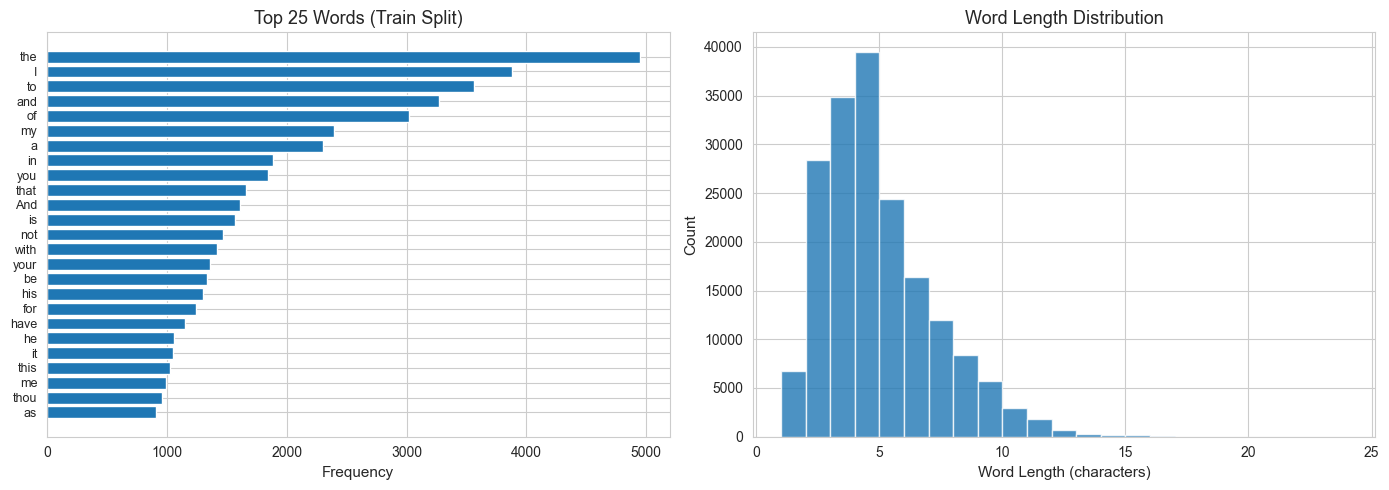

In [10]:
words = train_text.split()
word_counts = Counter(words)
word_lengths = [len(w) for w in words]

print(f"Total words: {len(words):,}")
print(f"Unique words: {len(word_counts):,}")
print(f"Avg word length: {np.mean(word_lengths):.2f} chars")
print(f"Median word length: {np.median(word_lengths):.0f} chars")
print(f"Max word length: {max(word_lengths)} chars")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_words = word_counts.most_common(25)
w_names, w_freqs = zip(*top_words)
axes[0].barh(range(len(w_names)), w_freqs)
axes[0].set_yticks(range(len(w_names)))
axes[0].set_yticklabels(w_names, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel("Frequency")
axes[0].set_title("Top 25 Words (Train Split)")

axes[1].hist(word_lengths, bins=range(1, max(word_lengths) + 2),
             edgecolor="white", alpha=0.8)
axes[1].set_xlabel("Word Length (characters)")
axes[1].set_ylabel("Count")
axes[1].set_title("Word Length Distribution")

plt.tight_layout()
plt.show()

## 3b. Line Length Distribution

Line length matters for context windows. Here the longest non-empty line is 63 chars, so every line fits inside `block_size=64`.

Total lines: 35,526
Empty lines: 6,284
Avg line length: 27.3 chars
Median line length: 36 chars
95th percentile: 50 chars
Max line length: 63 chars


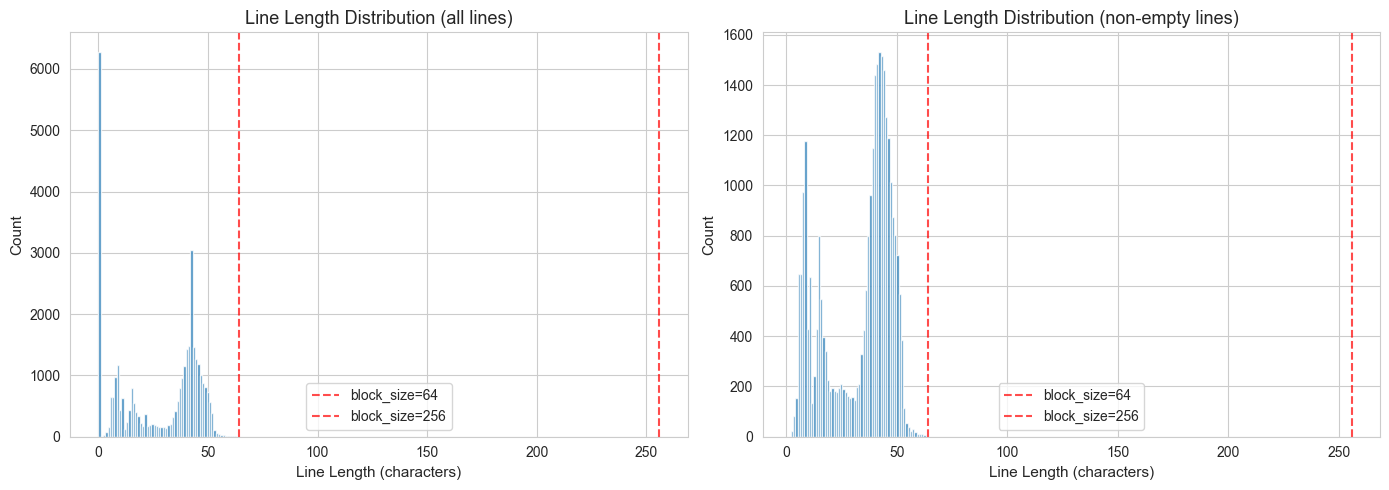


100.0% of non-empty lines fit within block_size=64
100.0% of non-empty lines fit within block_size=256


In [11]:
lines = train_text.split("\n")
line_lengths = [len(l) for l in lines]

print(f"Total lines: {len(lines):,}")
print(f"Empty lines: {sum(1 for l in line_lengths if l == 0):,}")
print(f"Avg line length: {np.mean(line_lengths):.1f} chars")
print(f"Median line length: {np.median(line_lengths):.0f} chars")
print(f"95th percentile: {np.percentile(line_lengths, 95):.0f} chars")
print(f"Max line length: {max(line_lengths)} chars")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(line_lengths, bins=60, edgecolor="white", alpha=0.8)
axes[0].set_xlabel("Line Length (characters)")
axes[0].set_ylabel("Count")
axes[0].set_title("Line Length Distribution (all lines)")
for bs in [64, 256]:
    axes[0].axvline(bs, color="red", linestyle="--", alpha=0.7, label=f"block_size={bs}")
axes[0].legend()

non_empty = [l for l in line_lengths if l > 0]
axes[1].hist(non_empty, bins=60, edgecolor="white", alpha=0.8)
axes[1].set_xlabel("Line Length (characters)")
axes[1].set_ylabel("Count")
axes[1].set_title("Line Length Distribution (non-empty lines)")
for bs in [64, 256]:
    axes[1].axvline(bs, color="red", linestyle="--", alpha=0.7, label=f"block_size={bs}")
axes[1].legend()

plt.tight_layout()
plt.show()

pct_under_64 = sum(1 for l in non_empty if l <= 64) / len(non_empty) * 100
pct_under_256 = sum(1 for l in non_empty if l <= 256) / len(non_empty) * 100
print(f"\n{pct_under_64:.1f}% of non-empty lines fit within block_size=64")
print(f"{pct_under_256:.1f}% of non-empty lines fit within block_size=256")

## 3c. Character-Level Vocabulary

The proposal specifies a character-level tokenizer producing a vocabulary of **~65 unique characters** (proposal §2). This keeps the embedding table small and training fast.

In [12]:
vocab = sorted(set(train_text))
print(f"Vocabulary size: {len(vocab)}")
print(f"Characters: {vocab}")

non_printable = [c for c in vocab if not c.isprintable() and c not in ("\n", "\t")]
if non_printable:
    print(f"\n⚠ Non-printable characters found: {[repr(c) for c in non_printable]}")
else:
    print("\nNo unexpected non-printable characters.")

Vocabulary size: 65
Characters: ['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']

No unexpected non-printable characters.


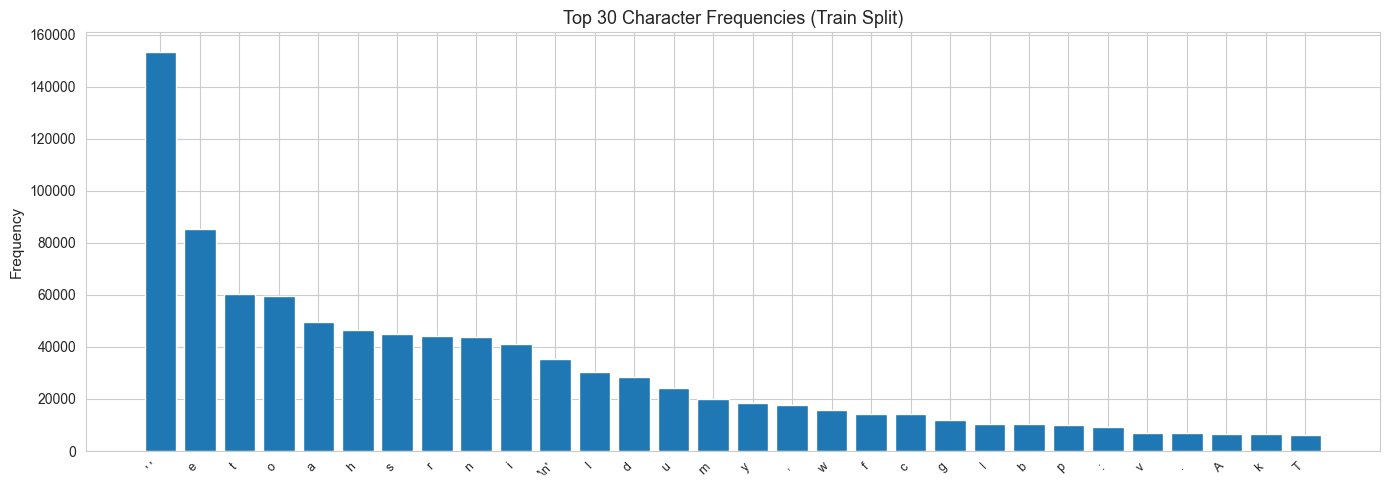

In [13]:
char_counts = Counter(train_text)
chars, counts = zip(*char_counts.most_common(30))
labels = [repr(c) if not c.strip() else c for c in chars]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(labels)), counts)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Frequency")
ax.set_title("Top 30 Character Frequencies (Train Split)")
plt.tight_layout()
plt.show()

## 4. Shakespearean Structure — Speaker & Dialogue Analysis

Lines matching the pattern `^NAME:` indicate a character's dialogue turn. The model must learn to reproduce this `CHARACTER_NAME:` → dialogue structure (proposal §7 qualitative evaluation). We also measure dialogue lengths per speaker to understand the range of output the model should produce.

Unique speakers: 154
Total dialogue turns: 5,237


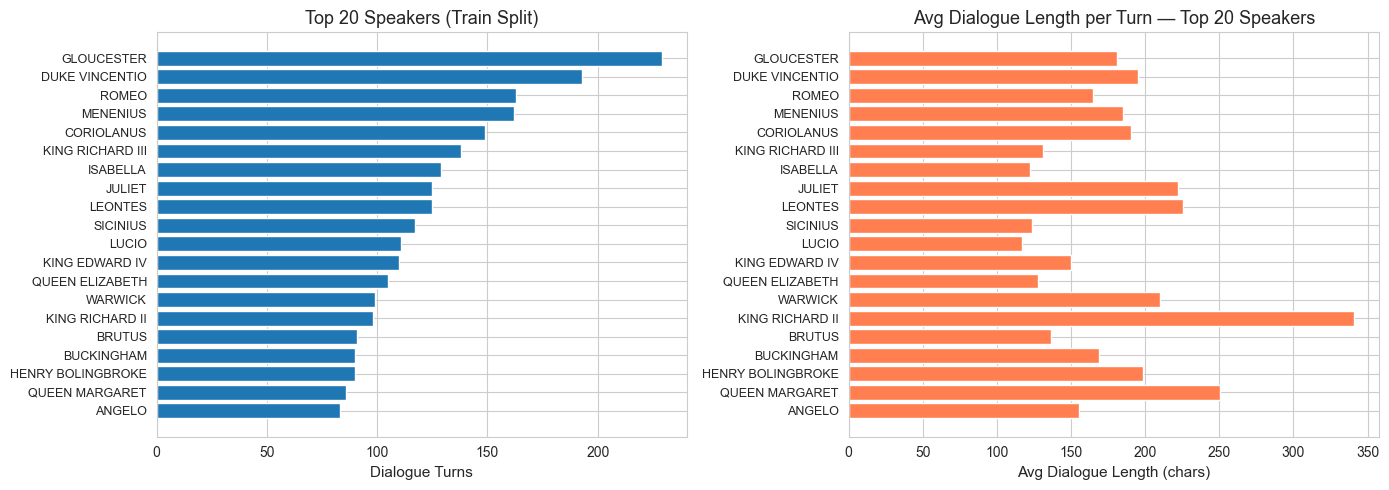


Dialogue turn length stats:
  Mean: 178 chars | Median: 88 chars
  95th pctl: 609 chars | Max: 6867 chars


In [14]:
speaker_pattern = re.compile(r"^([A-Z][A-Z ]+):", re.MULTILINE)
speakers = speaker_pattern.findall(train_text)
speaker_counts = Counter(speakers)

print(f"Unique speakers: {len(speaker_counts)}")
print(f"Total dialogue turns: {len(speakers):,}")

turn_pattern = re.compile(r"^([A-Z][A-Z ]+):\n(.*?)(?=\n[A-Z][A-Z ]+:|\Z)", re.MULTILINE | re.DOTALL)
turns = turn_pattern.findall(train_text)
dialogue_lengths = {}
for name, dialogue in turns:
    dialogue_lengths.setdefault(name, []).append(len(dialogue.strip()))

top_n = 20
top_speakers = speaker_counts.most_common(top_n)
names, freqs = zip(*top_speakers)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(range(len(names)), freqs)
axes[0].set_yticks(range(len(names)))
axes[0].set_yticklabels(names, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel("Dialogue Turns")
axes[0].set_title(f"Top {top_n} Speakers (Train Split)")

top_dl = {n: dialogue_lengths.get(n, []) for n in names}
avg_lens = [np.mean(top_dl[n]) if top_dl[n] else 0 for n in names]
axes[1].barh(range(len(names)), avg_lens, color="coral")
axes[1].set_yticks(range(len(names)))
axes[1].set_yticklabels(names, fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel("Avg Dialogue Length (chars)")
axes[1].set_title(f"Avg Dialogue Length per Turn — Top {top_n} Speakers")

plt.tight_layout()
plt.show()

all_dl = [l for ls in dialogue_lengths.values() for l in ls]
print(f"\nDialogue turn length stats:")
print(f"  Mean: {np.mean(all_dl):.0f} chars | Median: {np.median(all_dl):.0f} chars")
print(f"  95th pctl: {np.percentile(all_dl, 95):.0f} chars | Max: {max(all_dl)} chars")

## 4a. Act & Scene Structure

The corpus contains stage directions and act/scene headers. Understanding their frequency helps us gauge how much structural formatting the model needs to learn beyond raw dialogue.

Act headers found:        0
Scene headers found:      0
Stage directions [...]:   0
Dialogue turns:           5,237


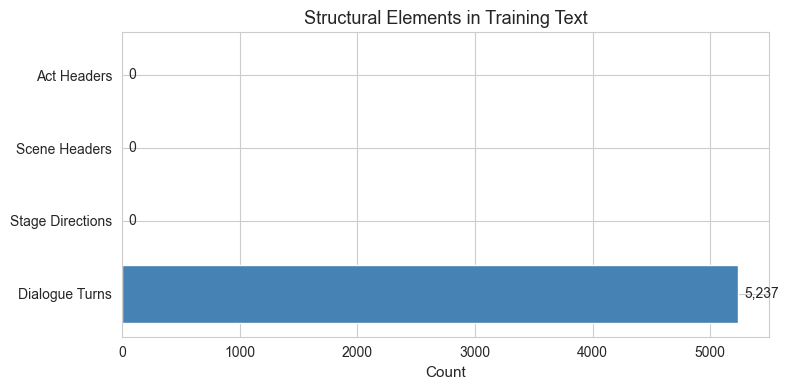

In [15]:
act_pattern = re.compile(r"^ACT [IVX]+", re.MULTILINE)
scene_pattern = re.compile(r"^SCENE [IVX]+", re.MULTILINE)
stage_dir_pattern = re.compile(r"\[.*?\]")

acts = act_pattern.findall(train_text)
scenes = scene_pattern.findall(train_text)
stage_dirs = stage_dir_pattern.findall(train_text)

print(f"Act headers found:        {len(acts)}")
print(f"Scene headers found:      {len(scenes)}")
print(f"Stage directions [...]:   {len(stage_dirs)}")
print(f"Dialogue turns:           {len(speakers):,}")

categories = ["Dialogue Turns", "Stage Directions", "Scene Headers", "Act Headers"]
counts = [len(speakers), len(stage_dirs), len(scenes), len(acts)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(categories, counts, color=["steelblue", "coral", "seagreen", "goldenrod"])
ax.set_xlabel("Count")
ax.set_title("Structural Elements in Training Text")
for i, v in enumerate(counts):
    ax.text(v + max(counts) * 0.01, i, f"{v:,}", va="center", fontsize=10)
plt.tight_layout()
plt.show()

## 5. Chunking / Context-Length Preview

We compare a few `block_size` values. Since every line is under 64 chars, `64` is already line-safe; larger windows mainly give the model more surrounding context.

Below we:
- Build a character tokenizer and verify encode/decode.
- Count training examples per `block_size`.
- Show the raw text window and token IDs the model sees.

block_size=  32  →  31,370 training examples
block_size=  64  →  15,685 training examples
block_size= 128  →   7,842 training examples
block_size= 256  →   3,921 training examples
block_size= 512  →   1,960 training examples

--- Round-trip verification (block_size=64) ---
Text:    'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAl'
Encoded: [18, 47, 56, 57, 58, 1, 15, 47, 58, 47, 64, 43, 52, 10, 0, 14, 43, 44, 53, 56, 43, 1, 61, 43, 1, 54, 56, 53, 41, 43, 43, 42, 1, 39, 52, 63, 1, 44, 59, 56, 58, 46, 43, 56, 6, 1, 46, 43, 39, 56, 1, 51, 43, 1, 57, 54, 43, 39, 49, 8, 0, 0, 13, 50]
Decoded: 'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAl'
Round-trip OK: True


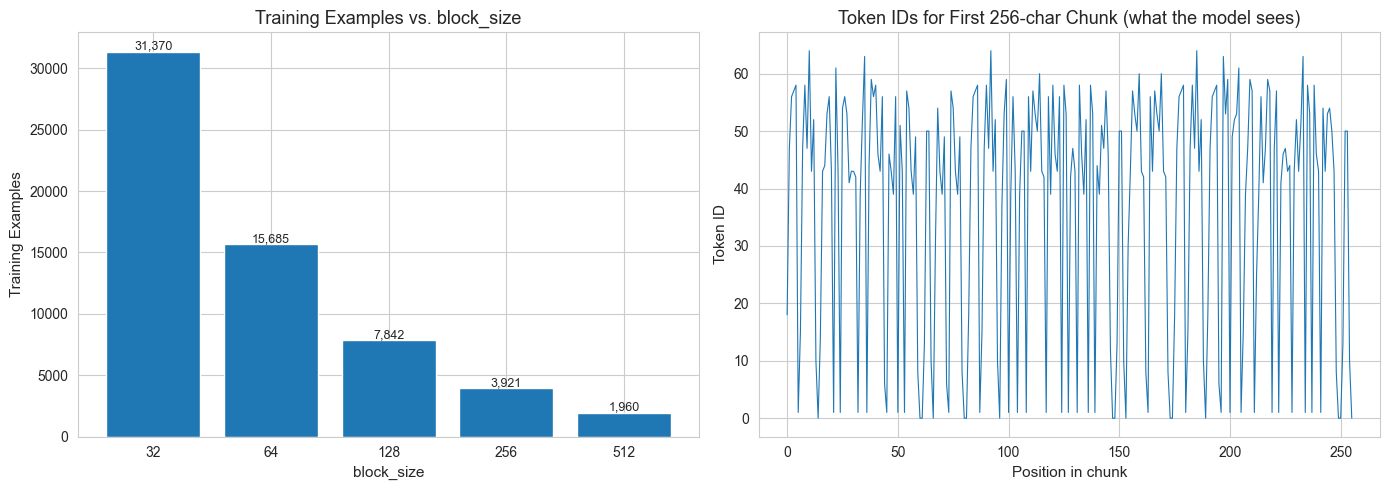

In [16]:
stoi = {ch: i for i, ch in enumerate(vocab)}
itos = {i: ch for ch, i in stoi.items()}

encode = lambda s: [stoi[c] for c in s]
decode = lambda l: "".join(itos[i] for i in l)

block_sizes = [32, 64, 128, 256, 512]
rows_bs = []
for bs in block_sizes:
    n = (len(train_text) - 1) // bs
    rows_bs.append({"block_size": bs, "training_examples": n})
    print(f"block_size={bs:>4}  →  {n:>6,} training examples")

print("\n--- Round-trip verification (block_size=64) ---")
sample_chunk = train_text[:64]
encoded = encode(sample_chunk)
decoded = decode(encoded)
print(f"Text:    {repr(sample_chunk)}")
print(f"Encoded: {encoded}")
print(f"Decoded: {repr(decoded)}")
print(f"Round-trip OK: {sample_chunk == decoded}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar([str(bs) for bs in block_sizes],
            [r["training_examples"] for r in rows_bs])
axes[0].set_xlabel("block_size")
axes[0].set_ylabel("Training Examples")
axes[0].set_title("Training Examples vs. block_size")
for i, r in enumerate(rows_bs):
    axes[0].text(i, r["training_examples"] + 200, f"{r['training_examples']:,}",
                 ha="center", fontsize=9)

sample_256 = encode(train_text[:256])
axes[1].plot(sample_256, linewidth=0.8)
axes[1].set_xlabel("Position in chunk")
axes[1].set_ylabel("Token ID")
axes[1].set_title("Token IDs for First 256-char Chunk (what the model sees)")

plt.tight_layout()
plt.show()

## 6. Train / Validation Split — Overfitting Risk

Validation is only ~5 % of the corpus. We check two things:
- **Split sizes** — how imbalanced the splits are.
- **Character-frequency correlation** — if train and validation come from similar text, points should fall on the diagonal.

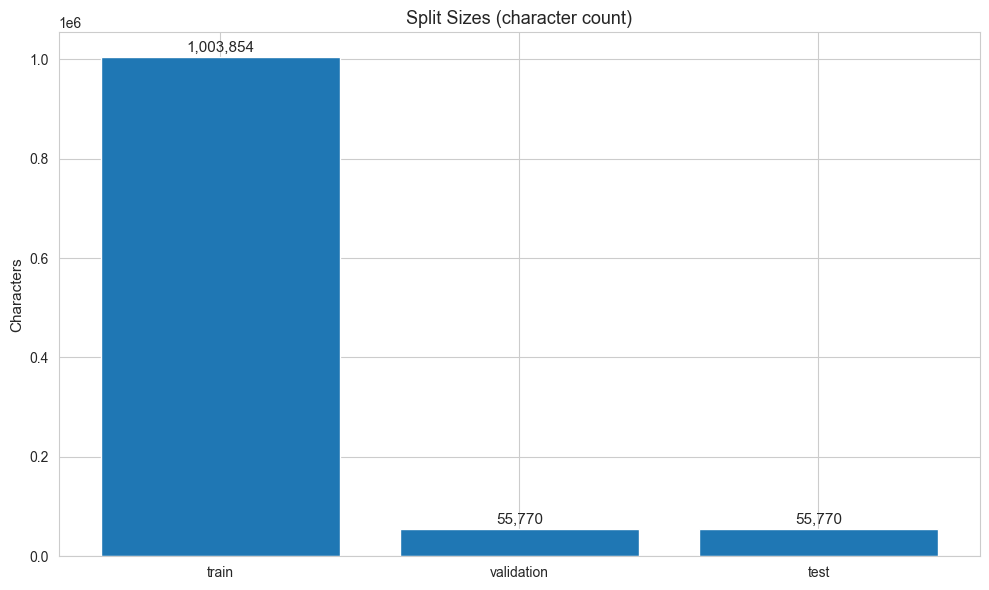

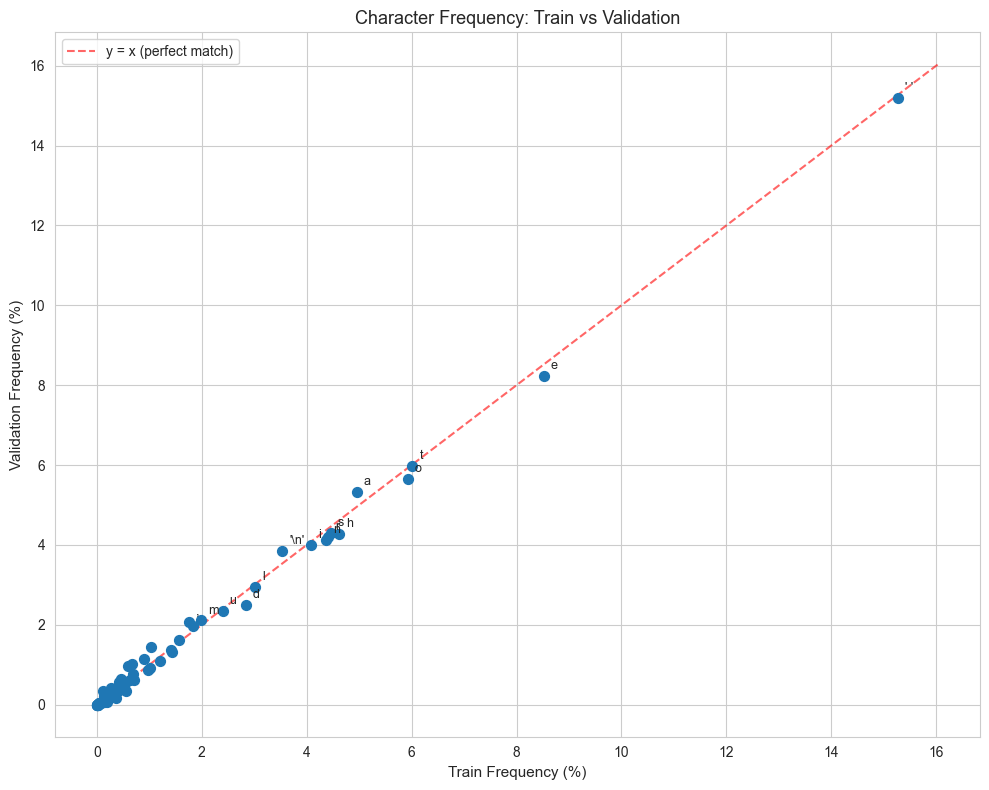

In [19]:
split_names = list(splits.keys())
split_sizes = [len(t) for t in splits.values()]

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(split_names, split_sizes)
ax.set_ylabel("Characters")
ax.set_title("Split Sizes (character count)")
for i, v in enumerate(split_sizes):
    ax.text(i, v + max(split_sizes) * 0.01, f"{v:,}", ha="center", fontsize=11)
plt.tight_layout()
plt.show()

train_freq = Counter(train_text)
val_freq = Counter(splits["validation"])
all_chars = sorted(set(train_freq.keys()) | set(val_freq.keys()))

train_total = sum(train_freq.values())
val_total = sum(val_freq.values())
train_pct = np.array([train_freq.get(c, 0) / train_total * 100 for c in all_chars])
val_pct = np.array([val_freq.get(c, 0) / val_total * 100 for c in all_chars])

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(train_pct, val_pct, s=50, zorder=3)
lo, hi = 0, max(train_pct.max(), val_pct.max()) * 1.05
ax.plot([lo, hi], [lo, hi], "r--", alpha=0.6, label="y = x (perfect match)")
for c, tp, vp in zip(all_chars, train_pct, val_pct):
    if tp > 2 or vp > 2:
        label = repr(c) if not c.strip() else c
        ax.annotate(label, (tp, vp), fontsize=9, textcoords="offset points", xytext=(5, 5))
ax.set_xlabel("Train Frequency (%)")
ax.set_ylabel("Validation Frequency (%)")
ax.set_title("Character Frequency: Train vs Validation")
ax.legend()
plt.tight_layout()
plt.show()

**Observations:**

- **Split imbalance is extreme.** Train holds ~1M chars (~90 %), while validation and test each hold ~56K chars (~5 %). With so little held-out data, even small improvements in loss can be noisy — early stopping and multiple seeds will matter.
- **Character distributions are nearly identical.** Every point in the scatter plot sits on or very close to the `y = x` diagonal. This means there is no domain shift between splits: validation loss is a reliable proxy for generalization on this corpus.

## Key Takeaways & Architecture Implications

| Finding | Implication for Model Design (proposal §4, §5, §9) |
|---|---|
| **~65 unique characters** | Character-level tokenization is enough here. |
| **~1M characters, ~200k words** | The corpus is small, so larger models can memorize fast. |
| **Consistent `NAME:` → dialogue structure** | Qualitative eval should check this pattern. |
| **All non-empty lines fit under 64 chars** | `block_size=64` covers single lines; `256` adds broader context. |
| **Validation ≈ 5% of corpus** | Watch overfitting with dropout, clipping, and early stopping. |
| **Similar char distributions across splits** | Validation loss should be a useful signal. |
| **40+ speakers, varied dialogue lengths** | The model needs to learn more than one speaking style. |